# LaTe2 CDW walkthrough - Phase A

Reproduces the Alekseev PRB 110, 205103 (2024) machinery at RTE2 band filling. Matches the two in-house TEM q values: **q approx 0.15 a\*** (incommensurate) and **q approx 0.25 a\*** (discommensurate).

The 2-orbital Alekseev form was insufficient (structurally diagonal-nesting). Phase A extended the Hamiltonian with a second-neighbor 2D-dispersive term (t_2). The fit captures axial dominance and the q_low peak quantitatively; q_high is reproduced only qualitatively.


In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd()))

import numpy as np
import matplotlib.pyplot as plt

from tem_cdw import hamiltonian, susceptibility, gl_theory, fermi_surface, orbital_density
from tem_cdw.hamiltonian import TBParams, h_k, bands_and_projectors, make_bz_grid
from tem_cdw.susceptibility import susceptibility_tensor, chi_combinations
from tem_cdw.gl_theory import quadratic_coeffs, quartic_coeffs, coexistence_criterion
from tem_cdw.fermi_surface import cdw_order_matrix
from tem_cdw.orbital_density import orbital_amplitudes, real_space_density
from tem_cdw.models import LaTe2Model
from tem_cdw.units import astar_from_q, q_from_astar, TWO_PI

OUTDIR = pathlib.Path('figures/rte2_phase_a'); OUTDIR.mkdir(parents=True, exist_ok=True)


In [2]:
material = LaTe2Model()
print('Fitted LaTe2 TB parameters (Phase A+ with t_2 extension):')
print(f'  t_sigma = {material.params.t_sigma:.4f}')
print(f'  t_pi    = {material.params.t_pi:.4f}')
print(f'  t_d     = {material.params.t_d:.4f}')
print(f'  t_2     = {material.params.t_2:.4f}')
print(f'  mu      = {material.params.mu:.4f}')


Fitted LaTe2 TB parameters (Phase A+ with t_2 extension):
  t_sigma = 2.5997
  t_pi    = 0.3011
  t_d     = 0.0105
  t_2     = -0.4386
  mu      = -3.1151


## Fig. 1 - Fermi surface with orbital texture
Diamond-shape FS in (a*, b*) plane, colored by |a_px|^2 (green) and |a_py|^2 (red). Nesting arrows for q_low and q_high overlaid.


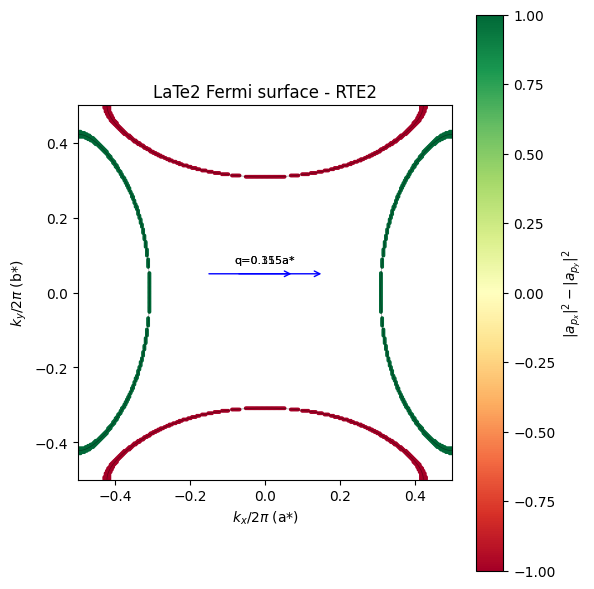

In [3]:
def plot_fig1_late2(material, nk=400, savepath=None):
    p = material.params
    kg = np.linspace(-np.pi, np.pi, nk)
    KX, KY = np.meshgrid(kg, kg, indexing='ij')
    eps, avec = bands_and_projectors(KX, KY, p)
    lower = eps[..., 0] - p.mu
    wpx = np.abs(avec[..., 0, 0]) ** 2
    wpy = np.abs(avec[..., 1, 0]) ** 2

    fig, ax = plt.subplots(figsize=(6, 6))
    ax.contour(KX / TWO_PI, KY / TWO_PI, lower, levels=[0.0], colors='k',
               linewidths=0.5, alpha=0.4)
    mask = np.abs(lower) < 0.05
    if mask.any():
        sc = ax.scatter((KX / TWO_PI)[mask], (KY / TWO_PI)[mask],
                        c=(wpx - wpy)[mask], cmap='RdYlGn', s=3,
                        vmin=-1, vmax=1)
        plt.colorbar(sc, ax=ax, label=r'$|a_{p_x}|^2 - |a_{p_y}|^2$')

    result = material.find_Q0(T=0.026, nk_bz=80, nk_q=40)
    for (qx, qy) in result.peaks:
        q_astar = qx / TWO_PI
        ax.annotate('', xy=(q_astar/2, 0.05), xytext=(-q_astar/2, 0.05),
                    arrowprops=dict(arrowstyle='->', color='blue'))
        ax.text(0, 0.08, f'q={q_astar:.3f}a*', ha='center', fontsize=8)

    ax.set_xlabel(r'$k_x / 2\pi$ (a*)')
    ax.set_ylabel(r'$k_y / 2\pi$ (b*)')
    ax.set_title(f'LaTe2 Fermi surface - {material.name}')
    ax.set_aspect('equal')
    ax.set_xlim(-0.5, 0.5); ax.set_ylim(-0.5, 0.5)
    fig.tight_layout()
    if savepath: fig.savefig(savepath, dpi=150)
    return fig

fig = plot_fig1_late2(material, nk=300, savepath=OUTDIR / 'fig1_fermi_surface.png')
plt.show()


## Fig. 2 - chi(q) scan along a* and diagonal
Axial (solid) vs diagonal (dashed control) susceptibility at three temperatures.


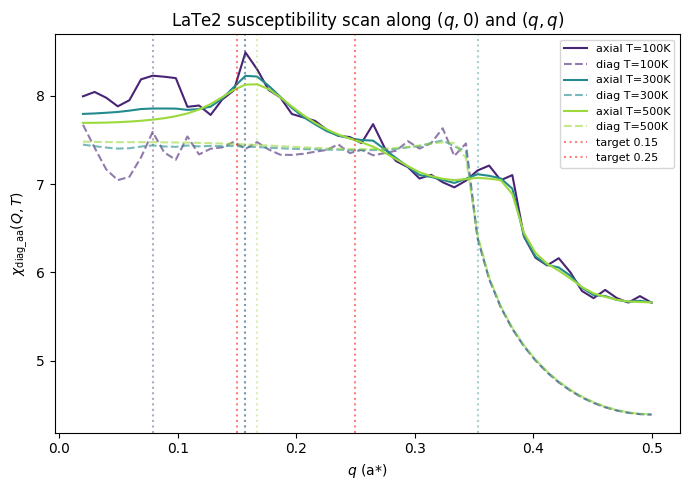

In [4]:
temps_K = [100, 300, 500]
temps_eV = [T * 8.617e-5 for T in temps_K]

fig, ax = plt.subplots(figsize=(7, 5))
colors = plt.cm.viridis(np.linspace(0.1, 0.85, len(temps_eV)))
for T_eV, T_K, c in zip(temps_eV, temps_K, colors):
    result = material.find_Q0(T=T_eV, nk_bz=100, nk_q=50)
    q_astar = result.q_grid / TWO_PI
    ax.plot(q_astar, result.chi_axial, '-', color=c, label=f'axial T={T_K}K')
    ax.plot(q_astar, result.chi_diagonal, '--', color=c, alpha=0.6, label=f'diag T={T_K}K')
    for qx, _ in result.peaks:
        ax.axvline(qx / TWO_PI, color=c, ls=':', alpha=0.4)

ax.axvline(0.15, color='r', ls=':', alpha=0.5, label='target 0.15')
ax.axvline(0.25, color='r', ls=':', alpha=0.5, label='target 0.25')
ax.set_xlabel(r'$q$ (a*)')
ax.set_ylabel(r'$\chi_{\rm diag\_aa}(Q, T)$')
ax.set_title(r'LaTe2 susceptibility scan along $(q, 0)$ and $(q, q)$')
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(OUTDIR / 'fig2_chi_scan.png', dpi=150)
plt.show()


## Fig. 3 - chi(Q_peak, T) vs T for both Q0 candidates


In [5]:
result_ref = material.find_Q0(T=0.02, nk_bz=100, nk_q=50)
assert len(result_ref.peaks) == 2, 'Expected 2 Q peaks; got ' + str(result_ref.peaks)
Q_low, Q_high = result_ref.peaks
print(f'Q_low  = {Q_low[0]/TWO_PI:.4f} a*')
print(f'Q_high = {Q_high[0]/TWO_PI:.4f} a*')


Q_low  = 0.0788 a*
Q_high = 0.1571 a*


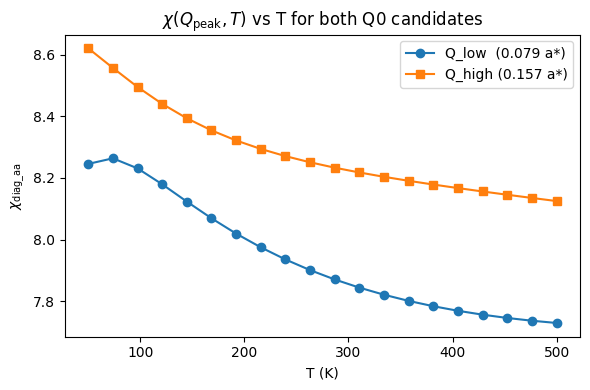

In [6]:
T_K_grid = np.linspace(50, 500, 20)
T_eV_grid = T_K_grid * 8.617e-5

chi_low = np.empty_like(T_eV_grid)
chi_high = np.empty_like(T_eV_grid)
for i, T in enumerate(T_eV_grid):
    chi_l = susceptibility_tensor(Q_low[0],  Q_low[1],  T, material.params, nk=100)
    chi_h = susceptibility_tensor(Q_high[0], Q_high[1], T, material.params, nk=100)
    chi_low[i]  = chi_combinations(chi_l)['diag_aa']
    chi_high[i] = chi_combinations(chi_h)['diag_aa']

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(T_K_grid, chi_low,  'o-', label=f'Q_low  ({Q_low[0]/TWO_PI:.3f} a*)')
ax.plot(T_K_grid, chi_high, 's-', label=f'Q_high ({Q_high[0]/TWO_PI:.3f} a*)')
ax.set_xlabel('T (K)'); ax.set_ylabel(r'$\chi_{\rm diag\_aa}$')
ax.set_title(r'$\chi(Q_{\rm peak}, T)$ vs T for both Q0 candidates')
ax.legend(); fig.tight_layout()
fig.savefig(OUTDIR / 'fig3_chi_vs_T.png', dpi=150)
plt.show()


## Fig. 4 - Quadratic GL coefficient $a_-(T)$ at both Q0


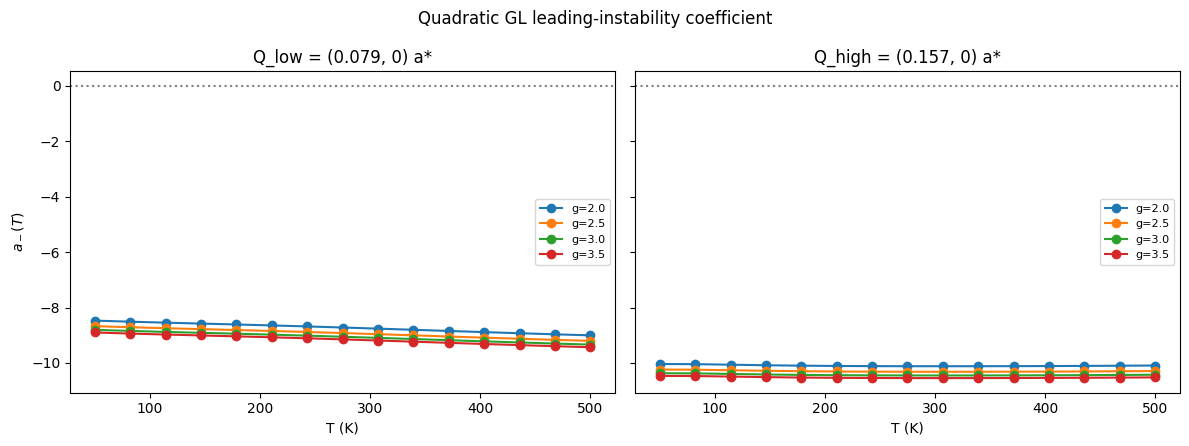

In [7]:
g_values = [2.0, 2.5, 3.0, 3.5]
T_K_grid = np.linspace(50, 500, 15)
T_eV_grid = T_K_grid * 8.617e-5

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
for ax, (Q_label, Q) in zip(axes, [('Q_low', Q_low), ('Q_high', Q_high)]):
    for g in g_values:
        a_minus = np.empty_like(T_eV_grid)
        for i, T in enumerate(T_eV_grid):
            qc = quadratic_coeffs(Q[0], Q[1], T, material.params, g=g, nk=100)
            am, _, _, _ = qc.diagonalize()
            a_minus[i] = am
        ax.plot(T_K_grid, a_minus, 'o-', label=f'g={g}')
    ax.axhline(0, color='k', ls=':', alpha=0.5)
    ax.set_xlabel('T (K)'); ax.set_title(f'{Q_label} = ({Q[0]/TWO_PI:.3f}, 0) a*')
    ax.legend(fontsize=8)
axes[0].set_ylabel(r'$a_-(T)$')
fig.suptitle('Quadratic GL leading-instability coefficient')
fig.tight_layout()
fig.savefig(OUTDIR / 'fig4_quadratic_gl.png', dpi=150)
plt.show()
